In [19]:
import seaborn as sns
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter

sns.set()

api = wandb.Api()

project = api.runs("naoki-shitanda/sapg_shadow_hand")
task_name = "ShadowHand"
metric = "rewards/step"
metric_name = "Episode Rewards"

target_steps = [2e10]

print(len(project))    

# ラベル名と検索キーのマッピング
method_config = {
    "SAPG": {
        "search_key": "CPO3_SAPG",
        "color": "green",
        "style": (10, (5, 3, 1, 3, 1, 3))
    },
    "PPO": {
        "search_key": "CPO3_PPO", 
        "color": "blue",
        "style": ":"
    },
    "PBT": {
        "search_key": "CPO3_PBT",
        "color": "purple", 
        "style": "-."
    },
    "CPO": {
        "search_key": "CPO3_CPO0.2_adrew0.01",
        "color": "red",
        "style": "-"
    }
}

task_runs = {}

# 各手法の検索キーに基づいてrunを抽出
for label, config in method_config.items():
    search_key = config["search_key"]
    task_runs[label] = []
    for run in project:
        if any(search_key == tag for tag in run.tags):
            task_runs[label].append(run)

print(task_runs)
for key in task_runs.keys():
    print(key,":", len(task_runs[key]))

200
{'SAPG': [<Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_27_04_09h32m51s_seed4 (failed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_26_04_07h07m16s_seed3 (failed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_18_04_00h10m36s_seed2 (failed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_29_03_10h12m08s_seed1 (crashed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_29_03_10h11m42s_seed0 (crashed)>], 'PPO': [<Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-PPO-24576_24576envs_none_none_1p_25_04_23h46m39s_seed4 (failed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-PPO-24576_24576envs_none_none_1p_25_04_23h42m28s_seed3 (failed)>, <Run naoki-shitanda/sapg_shadow_hand/uid_00_0328-PPO-24576_24576envs_none_none_1p_18_

In [20]:
def calc_mean_std(runs, metric="rewards/step"):
    
    seed_dfs = []
    seeds = [run.config.get("seed", "not found") for run in runs]
    seed_set = set(seeds)
    
    # seedごとにデータを取得
    for seed in seed_set:
        print(seed, end=":")
        seed_runs = [run for run in runs if run.config.get("seed") == seed]
        seed_runs = sorted(seed_runs, key=lambda run: run.created_at) # 古い順に並べる
        dfs = []
        
        for i in range(len(seed_runs)):
            df = seed_runs[i].history(keys=[metric, "global_step"])
            df = df.set_index("global_step")
            df = df.dropna() # 欠損値を削除
            
            if i > 0:
                df = df.iloc[40:] # 先頭の行を削除
                # 前のrunの最後のglobal_stepより大きい値のみを保持
                if len(dfs) > 0:
                    last_step = dfs[-1].index.max()
                    df = df[df.index > last_step]
                
            dfs.append(df)
        
        # 連結前にインデックスが単調増加になるようにソート
        seed_df = pd.concat(dfs, axis=0)
        seed_df = seed_df.sort_index()  # global_stepでソート
        
        # 重複するインデックスを削除（最後のものを保持）
        seed_df = seed_df[~seed_df.index.duplicated(keep='last')]
        
        seed_df = seed_df.rename(columns={metric: f"seed{seed}"})    
        if "_step" in seed_df.columns:
            seed_df = seed_df.drop("_step", axis=1) # seed_dfから_stepを削除
    
        seed_dfs.append(seed_df)
        
    # 各seedのデータを連結して1つのデータフレームにする
    merged = pd.concat(seed_dfs, axis=1)
    
    # インデックスをソートして単調増加にする
    merged = merged.sort_index()
    
    # 内挿
    merged = merged.interpolate(method="linear", limit_direction="both")
    
    # 平均と標準偏差を計算
    mean = merged.mean(axis=1)
    std = merged.std(axis=1)
    
    return mean, std

SAPG : 0:1:2:3:4:
PPO : 0:1:2:3:4:
PBT : 0:1:2:3:4:
CPO : 0:1:2:3:4:


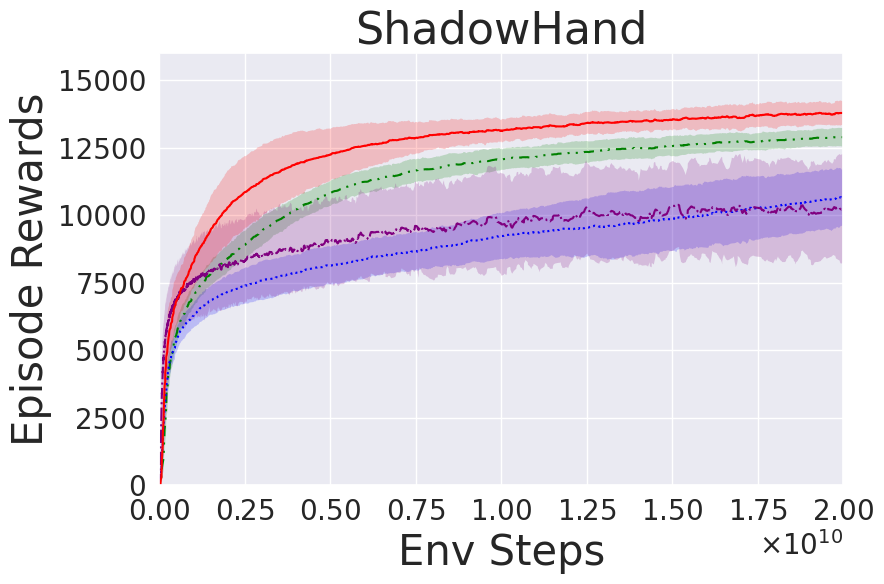

In [21]:
plt.figure(figsize=(9, 6))

for label in task_runs.keys():
    if len(task_runs[label]) == 0:
        continue
    print(label, ": ", end="")
    runs = task_runs[label]
    mean, std = calc_mean_std(runs, metric=metric)
    config = method_config[label]
    plt.plot(mean.index, mean.values, label=label, 
             color=config["color"], linestyle=config["style"])
    plt.fill_between(mean.index, mean - std, mean + std, alpha=0.2, 
                     color=config["color"], edgecolor="none")
    print("")

plt.xlabel("Env Steps", fontsize=30)
plt.ylabel(metric_name, fontsize=30)
plt.title(task_name, fontsize=32)
plt.grid(True)
plt.xlim(0, 2e10)
if "Humanoid" in task_name:
    plt.xlim(0, 1.0e10) # Humanoid
elif "Anymal" in task_name:
    plt.xlim(0, 5e9)

plt.ylim(0, 16000) # Allegro Hand
if "Shadow " in task_name:
    plt.ylim(0, 14500) # Shadow
elif "Allegro Hand" in task_name:
    plt.ylim(0, 16000) # Allegro Hand
elif "Humanoid" in task_name:
    plt.ylim(0, 11000)
elif "Anymal" in task_name:
    plt.ylim(0, 80)



plt.tight_layout(rect=[0, 0.07, 1, 1])




ax = plt.gca()
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # 必ず指数表記を使う
ax.xaxis.set_major_formatter(formatter)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(20)

plt.tick_params(axis='both', labelsize=20)  # 両軸の目盛を大きくする
plt.tight_layout()



plt.savefig("1_ShadowHand_reward.svg")

In [22]:
import torch
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind

# =========================
# データ抽出＋補間
# =========================

def extract_scores_at_step_interpolated(all_runs_dict, target_step, metric="rewards/step"):
    score_rows = []
    method_names = []
    all_seed_labels = []

    for method_name, runs in all_runs_dict.items():
        seed_scores = []
        seed_labels = []

        seeds = [run.config.get("seed", "not found") for run in runs]
        seed_set = set(seeds)

        for seed in seed_set:
            seed_runs = [run for run in runs if run.config.get("seed") == seed]
            seed_runs = sorted(seed_runs, key=lambda run: run.created_at)
            dfs = []

            for i, run in enumerate(seed_runs):
                df = run.history(keys=[metric, "global_step"])
                df = df.set_index("global_step")
                df = df.dropna()
                if i > 0:
                    df = df.iloc[40:]
                dfs.append(df)

            if len(dfs) == 0:
                continue

            seed_df = pd.concat(dfs, axis=0)
            seed_df = seed_df.rename(columns={metric: f"seed{seed}"})
            if "_step" in seed_df.columns:
                seed_df = seed_df.drop("_step", axis=1)

            seed_df = seed_df.sort_index()
            seed_df = seed_df.interpolate(method="linear", limit_direction="both")

            try:
                value = seed_df.loc[target_step].values[0]
            except KeyError:
                all_steps = seed_df.index.to_numpy()
                if target_step < all_steps[0] or target_step > all_steps[-1]:
                    continue
                lower_idx = max(i for i in range(len(all_steps)) if all_steps[i] <= target_step)
                upper_idx = min(i for i in range(len(all_steps)) if all_steps[i] >= target_step)
                lower = all_steps[lower_idx]
                upper = all_steps[upper_idx]
                val_lower = seed_df.loc[lower].values[0]
                val_upper = seed_df.loc[upper].values[0]
                weight = (target_step - lower) / (upper - lower + 1e-8)
                value = (1 - weight) * val_lower + weight * val_upper

            seed_scores.append(value)
            seed_labels.append(seed)

        if seed_scores:
            score_rows.append(seed_scores)
            method_names.append(method_name)
            all_seed_labels.append(seed_labels)

    max_seeds = max(len(row) for row in score_rows)
    padded = [row + [float('nan')] * (max_seeds - len(row)) for row in score_rows]
    tensor = torch.tensor(padded, dtype=torch.float32)
    return tensor, method_names, all_seed_labels

# =========================
# 信頼区間の計算
# =========================

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean().item()
    std = data.std(unbiased=True).item()
    h = stats.t.ppf((1 + confidence) / 2., n - 1) * std / np.sqrt(n)
    return mean, h

# =========================
# メイン出力処理
# =========================

def evaluate_and_report(all_runs_dict, target_step, metric_name, task_name=""):
    tensor, methods, seeds = extract_scores_at_step_interpolated(all_runs_dict, target_step, metric=metric_name)

    with open("output.txt", "w") as f:
        def print_both(text):  # inner function
            print(text)
            f.write(text + "\n")

        print_both("==========================")
        print_both(f"Task: {task_name}")
        print_both(f"Target Env Step: {target_step}")
        print_both(f"Metric: {metric_name}")
        print_both("--------------------------\n")

        ci_list = []
        for i, method in enumerate(methods):
            mean, h = confidence_interval(tensor[i])
            ci_list.append((method, mean, h, tensor[i].numpy()))
            print_both(f"{method}: {tensor[i].numpy()}")
            print_both(f"seeds: {seeds[i]}")
            mean_int = int(round(mean))
            std_int = int(round(tensor[i].std(unbiased=True).item()))
            print_both(f"mean: {mean_int}")
            print_both(f"std: {std_int}")
            #print_both(f"95% CI: [{mean - h:.3f}, {mean + h:.3f}]\n")
            print_both("--")
        ci_list_sorted = sorted(ci_list, key=lambda x: x[1], reverse=True)
        top_method = ci_list_sorted[0][0]
        top_mean, top_h, top_scores = ci_list_sorted[0][1], ci_list_sorted[0][2], ci_list_sorted[0][3]
        top_ci_lower = top_mean - top_h

        p_values = {}
        for method, mean, h, scores in ci_list:
            if method == top_method:
                continue
            _, p = ttest_ind(top_scores, scores, equal_var=False)
            p_values[method] = p

        top_tied_methods = [top_method] + [m for m in p_values if p_values[m] >= 0.05]
        sig_worse = [m for m in p_values if m not in top_tied_methods]

        print_both("==========================")
        print_both(f"✅ Top method by mean: {top_method}")
        print_both(f"Mean: {top_mean:.3f}, 95% CI: [{top_mean - top_h:.3f}, {top_mean + top_h:.3f}]\n")

        print_both("------ p-values vs top method (Welch's t-test) ------")
        for method, p in p_values.items():
            print_both(f"{method:15s}: p = {p:.4f}")

        print_both("\n------ Summary ------")
        if len(top_tied_methods) == 1:
            print_both(f"✅ Only '{top_method}' is significantly better than all others (p < 0.05)")
        else:
            print_both(f"✅ Statistically tied top methods (p ≥ 0.05 vs top): {', '.join(top_tied_methods)}")

        if sig_worse:
            print_both(f"⚠️  Methods significantly worse than '{top_method}' (p < 0.05): {', '.join(sig_worse)}")
        else:
            print_both(f"✅ No methods are significantly worse than '{top_method}'")

        print_both("\n--------------------------------------------------")
        print_both(f"Top: {top_method}")
        tied_others = [m for m in top_tied_methods if m != top_method]
        if tied_others:
            print_both(f"No Significant Difference: {', '.join(tied_others)}")
        else:
            print_both("No Significant Difference: (none)")

        if sig_worse:
            print_both(f"Significantly Worse: {', '.join(sig_worse)}")
        else:
            print_both("Significantly Worse: (none)")
        print_both("--------------------------------------------------")
        
        


In [23]:
for target_step in target_steps:
    print(f"Evaluating for target step: {target_step}")
    evaluate_and_report(
        all_runs_dict=task_runs,
        target_step=target_step,
        metric_name=metric,
        task_name=task_name,
    )


Evaluating for target step: 20000000000.0
Task: ShadowHand
Target Env Step: 20000000000.0
Metric: rewards/step
--------------------------

SAPG: [12656.981 12549.522 13430.575 12951.656 12820.365]
seeds: [0, 1, 2, 3, 4]
mean: 12882
std: 343
--
PPO: [11304.793 11094.453  9030.256 10232.545 11645.123]
seeds: [0, 1, 2, 3, 4]
mean: 10661
std: 1050
--
PBT: [ 7402.8823 10733.432  11833.254  10198.609  11300.511 ]
seeds: [0, 1, 2, 3, 4]
mean: 10294
std: 1728
--
CPO: [14105.308 14157.137 13177.019 13515.866 13856.885]
seeds: [0, 1, 2, 3, 4]
mean: 13762
std: 414
--
✅ Top method by mean: CPO
Mean: 13762.442, 95% CI: [13248.320, 14276.565]

------ p-values vs top method (Welch's t-test) ------
SAPG           : p = 0.0068
PPO            : p = 0.0014
PBT            : p = 0.0094

------ Summary ------
✅ Only 'CPO' is significantly better than all others (p < 0.05)
⚠️  Methods significantly worse than 'CPO' (p < 0.05): SAPG, PPO, PBT

--------------------------------------------------
Top: CPO
No Sig